In [1]:
#Dropping NaN Columns from combined sentences CSV

In [2]:
import pandas as pd

def load_and_clean(path):
    df = pd.read_csv(path)
    return df.dropna(subset=["Text"])

all_sentences = load_and_clean("combined_sentences.csv")
all_sentences.to_csv('cleaned_combined_sentences.csv', index=False)

print(all_sentences)

                                                      Text Language
0                                                     I am  English
1                                                        U  English
2                                                      him  English
3                                                      her  English
4                                                      you  English
...                                                    ...      ...
1252042  Idadi kubwa ya kampuni za ushirika zitashindan...  Swahili
1252043  Walifanya semina yao ya kila mwaka kuelimisha ...  Swahili
1252044  Uganda itakuwa ikituma kikundi chenye uwezo kw...  Swahili
1252045  Kocha anajiamini kuwa timu yake itashinda mchezo.  Swahili
1252046  Wauzaji watakuwa wakitoa huduma mbali mbali wa...  Swahili

[862882 rows x 2 columns]


In [3]:
# Balancing comlumns so that all have 4050 rows

In [4]:
# finding number of rows for each language

In [5]:
#English

In [6]:
import pandas as pd

df = pd.read_csv('cleaned_combined_sentences.csv')
count = (df['Language'] == 'English').sum()
print(count)

322071


In [7]:
# Kikuyu

In [8]:
import pandas as pd

df = pd.read_csv('cleaned_combined_sentences.csv')
count = (df['Language'] == 'Kikuyu').sum()
print(count)

106877


In [9]:
# Somali

In [10]:
import pandas as pd

df = pd.read_csv('cleaned_combined_sentences.csv')
count = (df['Language'] == 'Somali').sum()
print(count)

217415


In [11]:
#Sheng

In [12]:
import pandas as pd

df = pd.read_csv('cleaned_combined_sentences.csv')
count = (df['Language'] == 'Sheng').sum()
print(count)

1039


In [13]:
#Somali

In [14]:
import pandas as pd

df = pd.read_csv('cleaned_combined_sentences.csv')
count = (df['Language'] == 'Somali').sum()
print(count)

217415


In [15]:
# Balancing all other rows to match the language with the lowest number of rows, Sheng(1039)

In [16]:
import pandas as pd

df = pd.read_csv("cleaned_combined_sentences.csv")

sheng_df = df[df["Language"] == "Sheng"]

other_df = df[df["Language"] != "Sheng"]

balanced_others = (
    other_df.groupby("Language", group_keys=False)
            .apply(lambda x: x.sample(n=1039, random_state=42))
)

final_df = pd.concat([sheng_df, balanced_others], ignore_index=True)


final_df.to_csv("balanced_combined_sentences.csv", index=False)

print(final_df)

                                                   Text Language
0     So niaje aje, Paulo alikuwa bado akispit vitis...    Sheng
1     Akamshow niasaje, amgei ma letter kwa zile syn...    Sheng
2                                               Jerusa.    Sheng
3     Akikaribia kwa safari, akiona Damascus na far,...    Sheng
4     Akadunda kwa grao na kuskia sound ya voice iki...    Sheng
...                                                 ...      ...
5190                    Inaaminika kuwa mamia wamekufa.  Swahili
5191                          Je, una akaunti ya benki?  Swahili
5192                                  Waambie tu hapana  Swahili
5193               Yeye ndiye mkubwa kati ya hao wawili  Swahili
5194                 Ziara itakuwa katika mpango wangu.  Swahili

[5195 rows x 2 columns]


C:\Users\Wil\AppData\Local\Temp\ipykernel_5716\3001292268.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=1039, random_state=42))


In [17]:
import pandas as pd

df = pd.read_csv('balanced_combined_sentences.csv')
count = (df['Language'] == 'Kikuyu').sum()
print(count)

1039


In [4]:
#STEP 3 - Data Pre-Processing

In [3]:
import pandas as pd

df = pd.read_csv("data/balanced_combined_sentences.csv")

print(df.tail())
print(df['Language'].value_counts())

                                      Text Language
5190       Inaaminika kuwa mamia wamekufa.  Swahili
5191             Je, una akaunti ya benki?  Swahili
5192                     Waambie tu hapana  Swahili
5193  Yeye ndiye mkubwa kati ya hao wawili  Swahili
5194    Ziara itakuwa katika mpango wangu.  Swahili
Language
Sheng      1039
English    1039
Kikuyu     1039
Somali     1039
Swahili    1039
Name: count, dtype: int64


In [44]:
#removing special characters from Kikuyu sentences

In [45]:
import pandas as pd
import unicodedata

df = pd.read_csv("data/balanced_combined_sentences.csv")

def normalize_text(text):
    text = str(text).lower().strip()
    
    #Kikuyu diacritics to ASCII
    text = unicodedata.normalize('NFKD', text)
    text = text.encode('ascii', 'ignore').decode('utf-8')
    
    return text

df['clean_text'] = df['Text'].apply(normalize_text)

df.to_csv("data/ascii-balanced_combined_sentences.csv", index=False)

print(df)

                                                   Text Language  \
0     So niaje aje, Paulo alikuwa bado akispit vitis...    Sheng   
1     Akamshow niasaje, amgei ma letter kwa zile syn...    Sheng   
2                                               Jerusa.    Sheng   
3     Akikaribia kwa safari, akiona Damascus na far,...    Sheng   
4     Akadunda kwa grao na kuskia sound ya voice iki...    Sheng   
...                                                 ...      ...   
5190                    Inaaminika kuwa mamia wamekufa.  Swahili   
5191                          Je, una akaunti ya benki?  Swahili   
5192                                  Waambie tu hapana  Swahili   
5193               Yeye ndiye mkubwa kati ya hao wawili  Swahili   
5194                 Ziara itakuwa katika mpango wangu.  Swahili   

                                             clean_text  
0     so niaje aje, paulo alikuwa bado akispit vitis...  
1     akamshow niasaje, amgei ma letter kwa zile syn...  
2        

In [10]:
#Train/Test


Logistic Regression
              precision    recall  f1-score   support

     English       0.97      1.00      0.98       208
      Kikuyu       0.99      0.99      0.99       207
       Sheng       0.99      0.98      0.99       208
      Somali       1.00      0.99      0.99       208
     Swahili       0.98      0.97      0.97       208

    accuracy                           0.98      1039
   macro avg       0.98      0.98      0.98      1039
weighted avg       0.98      0.98      0.98      1039


Linear SVM
              precision    recall  f1-score   support

     English       0.98      1.00      0.99       208
      Kikuyu       1.00      0.98      0.99       207
       Sheng       1.00      1.00      1.00       208
      Somali       0.99      0.99      0.99       208
     Swahili       0.98      0.98      0.98       208

    accuracy                           0.99      1039
   macro avg       0.99      0.99      0.99      1039
weighted avg       0.99      0.99      0.99 

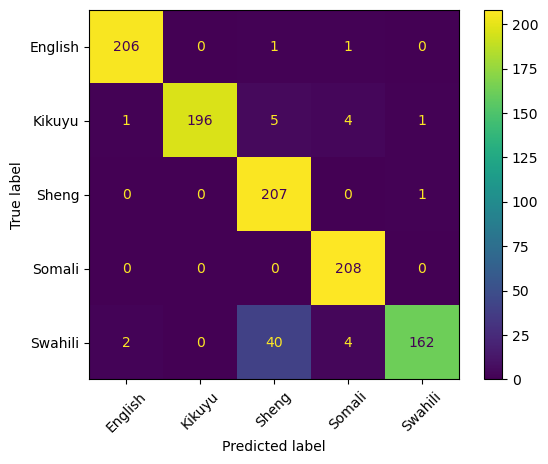

Cross-validation accuracy: 0.9376816625011571
Predicted as:
Sheng
English
Swahili
Somali
Somali
Kikuyu
Somali
Somali


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.model_selection import cross_val_score

df=pd.read_csv("data/ascii-balanced_combined_sentences.csv")

#Sheng slang handling
sheng_dict = {
    "broo": "bro",
    "bruh": "bro",
    "brathe": "bro",
    "mboka":"job",
    "brathee": "bro",
    "radaa": "rada",
    "fity": "fiti",
    "mse": "msee",
    "chwani":"fifty",
    "mseeh": "msee",
    "u": "you",
    "ur": "your",
    "doba":"music",
    "bt": "but",
    "coz": "because",
}

#Sheng pre-processing
def normalize_repetitions(word):
    return re.sub(r'(.)\1{2,}', r'\1', word)

def normalize_sheng_text(text):
    words = text.split()
    normalized_words = []

    for w in words:
        w = normalize_repetitions(w)
        w = sheng_dict.get(w, w)
        normalized_words.append(w)

    return " ".join(normalized_words)
    
def preprocess(text, lang):
    text = normalize_text(text)

    if lang == "Sheng":
        text = normalize_sheng_text(text)

    return text

df['clean_text'] = df.apply(
    lambda row: preprocess(row['Text'], row['Language']), axis=1
)

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['Language'],
    test_size=0.2,
    stratify=df['Language'],
    random_state=42
)

#Feature extraction -> Character n-gram
vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(1,5),
    min_df=2
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

#training models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB()
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

#Introducing confusion matrix
best_model = models["Naive Bayes"]

ConfusionMatrixDisplay.from_estimator(
    best_model, X_test_vec, y_test, xticks_rotation=45
)

#compare models
print("\nModel Accuracy Comparison:")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

plt.show()

scores = cross_val_score(best_model, X_train_vec, y_train, cv=5)
print("Cross-validation accuracy:", scores.mean())

#testing
def predict_language(text):
    text = normalize_text(text)
    vec = vectorizer.transform([text])
    return best_model.predict(vec)[0]

tests = [
    "niko job leo",
    "I am going to work",  
    "ninaenda kazini",       
    "rada, uko fiti?",
    "mboka doba",
    "reke guire",
    "maxaa jira?",
    "Sidee tahay?"
    ]

print("Predicted as:")
for t in tests:
    print(predict_language(t))
    

#Save models
# joblib.dump(model, "language_detector.pkl")
# joblib.dump(vectorizer, "vectorizer.pkl")
